# GFTM: is the large-WIDTH extent overshoot set by Gauss-Hermite node density or by NBASIS?

Fusion_PhD-38e9.12 (GFTM only). At large WIDTH GFTM's selected KBM is more extended than GS2's, and the
extent ratio rises with WIDTH (38e9.4 fig6, 38e9.6 fig2, 38e9.9). Two questions:

1. **Mathematics (Part A).** What limits GFTM's Hermite / Gauss-Hermite scheme from representing a narrow function:
   the node density, NBASIS, or both? Derived from GFTM's own source, checked on a Gaussian, then a
   **representability floor**: each GS2 KBM eigenfunction projected onto GFTM's basis on GFTM's nodes.
2. **Measurement (Part B).** Does GFTM's extent at each WIDTH converge as NXGRID/NBASIS rise, and to a
   WIDTH-independent value?

Scheme as GFTM implements it (source: `gftm_hermite.f90`, `gftm_geometry.f90:359-370`, `gftm_LS.f90` `get_wavefunction`):
- nodes: the `nx = 2*NXGRID-1` roots x_i of the Hermite polynomial H_nx (`gauher`), mapped to the ballooning angle
  theta_i = WIDTH * x_i (the straight-field-line angle 2 pi y/Ly);
- basis: NBASIS orthonormal Hermite functions psi_j(x) = h_j(x) exp(-x^2/2), j = 0..NBASIS-1, x = theta/WIDTH;
  the eigenfunction written out is sum_j c_j psi_j(theta/WIDTH) on a 289-point plot grid (+-9 pi);
- matrix elements: int psi_i psi_j f(theta) dx = int exp(-x^2) h_i h_j f(WIDTH x) dx by nx-point Gauss-Hermite, exact
  for polynomial integrands of degree <= 2nx-1. With f = const, h_i h_j has degree <= 2 NBASIS - 2, so exactness needs
  NBASIS <= nx = 2 NXGRID - 1: the valid window (with GFTM's array cap nb = 64, nxm = 129, `gftm_modules.f90`).

Settings: FILTER 0.5, NMODES 4, IBRANCH -1, FIND_WIDTH F, USE_BPAR from each case's `fbpar`. Dominant mode =
argmax growth over `mode`. GS2 reference: final-time eigenfunction of each linear run (projected in Part A) and
the `pyro_cube_avg` growth rate. Population: GS2-KBM cases (user classifier, `general_analysis.mode_classification`).

## Imports and settings

In [1]:
from pathlib import Path
import os
import warnings
from multiprocessing import get_context
from dotenv import load_dotenv
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from numpy.polynomial.hermite import hermgauss
import pyrokinetics
from pyrokinetics import Pyro
from pyrokinetics.pyroscan import PyroScanGKOutput
from pyrokinetics.diagnostics.extent import Extent
from general_analysis import mode_classification as mc

ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").is_file() and (path / "notebooks").is_dir()
)
plt.style.use(ROOT / "src/general_analysis/paper.mplstyle")
load_dotenv(ROOT / "local.env", override=True)
print("pyrokinetics", pyrokinetics.__version__)

analysis_name = "gftm_quadrature_extent"
data_root = Path(os.environ["GK_DATA_ROOT"]).expanduser()
project = "LATIN_HYPERCUBE"
cases = {"SPR-045": "SPR-045", "M1": "M1"}
fraction = 0.95                         # pyro Extent: theta range holding 95% of |field|^2
fields = ["phi", "apar"]
field_labels = {"phi": r"$\phi$", "apar": r"$A_\parallel$"}
widths = [0.4, 0.8, 1.74, 3.0, 4.0]
nxgrids = [17, 33, 49, 65]
# the two NBASIS arms of Fusion_PhD gftm_toolkit/settings/registry.py family gftm_quad_extent
arms = {"top": lambda nx: min(2 * nx - 1, 64), "nx-6": lambda nx: nx - 6}
reuse = {0.4: "w0p4000", 0.8: "w0p8000", 4.0: "w4p0000"}  # existing wo_f05 leaves, NXGRID 28 / NBASIS 22 (= nx-6 arm)
fs_title, fs_legend = 16, 12
wtag = lambda w: f"w{w:.4f}".replace(".", "p")
colours = dict(zip(widths, plt.cm.viridis(np.linspace(0, 0.9, len(widths)))))


def log_xticks(ax, ticks):
    lims = ax.get_xlim()
    ax.set_xticks(ticks)
    ax.set_xlim(lims)
    ax.xaxis.set_major_formatter(StrMethodFormatter("{x:g}"))
    ax.minorticks_off()

pyrokinetics 0.9.2.dev142+g959db5f4


## Part A1: GFTM's basis and nodes, and the two resolution scales

`basis(N, x)` is GFTM's recursion (`gftm_hermite.f90` `gauss_hermite`, `gftm_LS.f90` `get_wavefunction`), up to its
overall factor sqrt(2), which no extent sees. numpy's `hermgauss(n)` gives the same nodes as GFTM's `gauher` (n = 2 NXGRID - 1)
with weights for exp(-x^2), so `gftm_project` is the L2 projection onto the first N functions computed with GFTM's quadrature.

Scales near theta = 0, in theta:
- **basis**: psi_{N-1} has turning points at x = +-sqrt(2N-1) and N-1 zeros between, so its half-wavelength near 0 is
  ~ pi / sqrt(2N); the finest scale the basis carries is ~ WIDTH / sqrt(2N) (up to pi) and its envelope reaches ~ WIDTH sqrt(2N);
- **nodes**: central spacing ~ pi WIDTH / sqrt(2 nx), outermost node ~ WIDTH sqrt(2 nx), nx = 2 NXGRID - 1.

A Gaussian of width sigma, exp(-theta^2/2sigma^2), with s = sigma/WIDTH: its coefficient on psi_2k is
~ k^(-1/4) r^k with r = (1-s^2)/(1+s^2) (from int exp(-(1+b)x^2) H_2k dx = sqrt(pi/(1+b)) (2k)!/k! (-b/(1+b))^k, b = (1/s^2-1)/2).
The power left beyond N functions is ~ r^N ~ exp(-2 s^2 N) for s << 1, so holding all but a fraction eps needs
**N >~ (WIDTH/sigma)^2 ln(1/eps) / 2**: at fixed N the narrowest representable extent grows **in proportion to WIDTH**.
Inside the valid window (N <= nx) the central node spacing pi WIDTH/sqrt(2 nx) is never coarser than the basis scale
pi WIDTH/sqrt(2N), so **the basis count binds first and the nodes only cap N** (to 2 NXGRID - 1). The check below
tests that on Gaussians: if it is right, the smallest representable sigma is a fixed multiple of WIDTH/sqrt(2N), and
the extent responds to NBASIS much more than to NXGRID.
against sigma/(node spacing). Figure A1: a Gaussian of sigma = 0.3 (95% extent 0.83 rad) at each WIDTH, varying NBASIS at the
most nodes (left) and NXGRID at the most basis functions (right).

/tmp/ipykernel_3955079/1837322664.py:38: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  floor_sigma["c"] = floor_sigma.sigma_min / (floor_sigma.W / np.sqrt(2 * floor_sigma.nbasis))


nxgrid     17            33            49            65       
nbasis     11     33     27     64     43     64     59     64
W                                                             
0.40    0.152  0.087  0.100  0.062  0.076  0.066  0.066  0.066
0.80    0.304  0.174  0.200  0.123  0.163  0.132  0.132  0.132
1.74    0.652  0.374  0.430  0.264  0.349  0.283  0.283  0.283
3.00    1.135  0.652  0.749  0.461  0.608  0.494  0.494  0.494
4.00    1.499  0.860  0.988  0.608  0.803  0.652  0.652  0.652
sigma_min / (W/sqrt(2N)): median 1.793 range 1.719 - 1.886


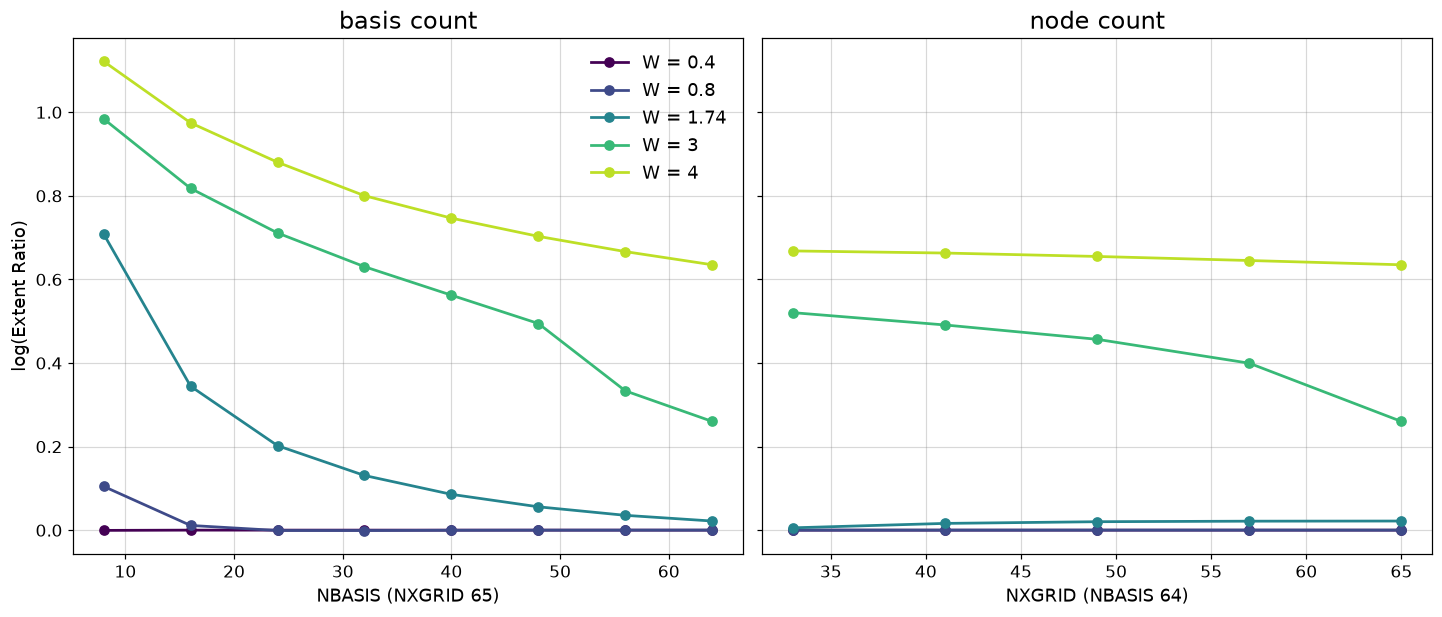

In [2]:
def basis(N, x):
    h = np.zeros((N, len(x)))
    h[0] = np.pi ** -0.25 * np.exp(-x ** 2 / 2)
    if N > 1:
        h[1] = np.sqrt(2) * x * h[0]
    for j in range(2, N):
        h[j] = np.sqrt(2 / j) * x * h[j - 1] - np.sqrt((j - 1) / j) * h[j - 2]
    return h


def gftm_project(theta_src, f_src, width, nb, nxgrid, theta_out):
    # f sampled at GFTM's nodes theta_i = WIDTH x_i (zero outside the source grid), projected with GFTM's quadrature
    x, w = hermgauss(2 * nxgrid - 1)
    fx = np.interp(width * x, theta_src, f_src.real, left=0, right=0) + 1j * np.interp(width * x, theta_src, f_src.imag, left=0, right=0)
    c = basis(nb, x) @ (w * np.exp(x ** 2) * fx)
    return c @ basis(nb, theta_out / width)


def extent(theta, power):
    return float(Extent._compute(xr.DataArray(power, dims="theta", coords={"theta": theta}), fraction)[0])


x0, _ = hermgauss(2 * 65 - 1)
assert abs(x0.max() - (np.sqrt(2 * 129 + 1) - 1.85575 * (2 * 129 + 1) ** (-1 / 6))) < 0.05   # gauher's initial guess
theta_fine = np.linspace(-9 * np.pi, 9 * np.pi, 4001)
cells = [(nx, f(nx)) for nx in nxgrids for f in arms.values()]


def gauss_ratio(sigma, W, nb, nx):
    g = np.exp(-theta_fine ** 2 / (2 * sigma ** 2))
    return extent(theta_fine, np.abs(gftm_project(theta_fine, g + 0j, W, nb, nx, theta_fine)) ** 2) / extent(theta_fine, g ** 2)


# (a) smallest Gaussian each cell represents to within x1.1 in extent, in units of the basis scale WIDTH/sqrt(2N)
sigmas = np.geomspace(0.05, 3, 60)
floor_sigma = pd.DataFrame([dict(W=W, nxgrid=nx, nbasis=nb, sigma_min=next(s for s in sigmas if gauss_ratio(s, W, nb, nx) < 1.1))
                            for W in widths for nx, nb in cells])
floor_sigma["c"] = floor_sigma.sigma_min / (floor_sigma.W / np.sqrt(2 * floor_sigma.nbasis))
print(floor_sigma.pivot_table(index="W", columns=["nxgrid", "nbasis"], values="sigma_min").round(3).to_string())
print("sigma_min / (W/sqrt(2N)): median", floor_sigma.c.median().round(3), "range", floor_sigma.c.min().round(3), "-", floor_sigma.c.max().round(3))

# (b) one narrow Gaussian: vary NBASIS at the most nodes (NXGRID 65), then vary NXGRID at NBASIS 64
sigma_A = 0.3
nb_axis, nx_axis = [8, 16, 24, 32, 40, 48, 56, 64], [33, 41, 49, 57, 65]
figA1, axesA1 = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
for W in widths:
    axesA1[0].plot(nb_axis, [np.log10(gauss_ratio(sigma_A, W, nb, 65)) for nb in nb_axis], color=colours[W], label=f"W = {W:g}")
    axesA1[1].plot(nx_axis, [np.log10(gauss_ratio(sigma_A, W, 64, nx)) for nx in nx_axis], color=colours[W])
axesA1[0].set(xlabel="NBASIS (NXGRID 65)", ylabel="log(Extent Ratio)")
axesA1[1].set(xlabel="NXGRID (NBASIS 64)")
axesA1[0].set_title("basis count", fontsize=fs_title)
axesA1[1].set_title("node count", fontsize=fs_title)
axesA1[0].legend(fontsize=fs_legend)
plt.show()

## GS2 reference: classification and eigenfunctions

Eigenfunctions (complex, final time) come from the GS2 `pyro_cube`, growth rates from `pyro_cube_avg` (tail average,
as the earlier KBM notebooks). The KBM label still loads each run, because no GS2 `pyroscan.nc` carries the tearing
parameter yet: replace `gs2_label` with the cube-based classify of Fusion_PhD-k8w8 when it merges.

In [3]:
def mag(v):
    return np.asarray(getattr(v.data, "magnitude", v.data))


def gs2_cube(db, kind):
    return PyroScanGKOutput.from_netcdf(data_root / "GS2" / "Runs" / project / cases[db] / "kbm_8d" / kind / "cube.nc")


def gs2_label(args):   # TEMPORARY per-run load, until Fusion_PhD-k8w8
    db, name = args
    try:
        pyro = Pyro(gk_file=data_root / "GS2" / "Runs" / project / cases[db] / "kbm_8d" / name / "gs2.in")
        pyro.load_gk_output(load_fields=True, load_fluxes=True)
        return mc.classify(mc.indicators(pyro))
    except Exception:
        return "load_failed"


warnings.filterwarnings("ignore")
gs2 = {}
for db in cases:
    last, avg = gs2_cube(db, "pyro_cube").data, gs2_cube(db, "pyro_cube_avg").data
    names = avg.sample_name.values.astype(str)
    assert (last.sample_name.values.astype(str) == names).all()
    ef = last.eigenfunctions.transpose("sample", "field", "theta")
    theta = mag(ef.theta)
    with get_context("fork").Pool(int(os.environ.get("SLURM_CPUS_PER_TASK", 4))) as pool:
        label = np.array(pool.map(gs2_label, [(db, n) for n in names], chunksize=4))
    g = mag(avg.growth_rate)
    gs2[db] = dict(names=names, label=label, gamma=g, theta=theta,
                   ef={f: mag(ef.sel(field=f)) for f in fields},              # (sample, theta), complex
                   kbm=(label == "KBM") & np.isfinite(g) & (g > 0))
    gs2[db]["ext"] = {f: np.array([extent(theta, np.abs(e) ** 2) for e in gs2[db]["ef"][f]]) for f in fields}
    print(db, pd.Series(label).value_counts().to_dict(), "| KBM population:", gs2[db]["kbm"].sum())
    print("   GS2 KBM extent median phi / A_par:", *[round(float(np.median(gs2[db]["ext"][f][gs2[db]["kbm"]])), 3) for f in fields],
          "| theta box max:", round(float(theta.max()), 2))

/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e912/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e912/.venv/lib/python3.14/site-packages/pyrokinetics/gk_code/gk_output.py:694: UserWarning: Mode frequency may not be accurate due to low temporal resolution
  warnings.warn(


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e912/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e912/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e912/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


...

/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e912/.venv/lib/python3.14/site-packages/pyrokinetics/pyro.py:1792: UserWarning: Explicitly set value of beta (0.05157967425275884 beta_ref_ee_B0_gs20039) is inconsistent with value from physical reference values (0.036316584746068435 beta_ref_ee_B0_gs20039)
  warnings.warn(


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e912/.venv/lib/python3.14/site-packages/pyrokinetics/gk_code/gk_output.py:694: UserWarning: Mode frequency may not be accurate due to low temporal resolution
  warnings.warn(


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e912/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis_38e912/.venv/lib/python3.14/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


M1 {'KBM': 167, 'mixed': 113, 'MTM': 20} | KBM population: 161
   GS2 KBM extent median phi / A_par: 2.664 2.505 | theta box max: 15.71


## Part B data: the convergence leaves

40 leaves per database (`qx_f05_<W>_nb<N>_nx<NX>`), plus the existing `wo_f05` leaves at NXGRID 28 / NBASIS 22 where the
WIDTH coincides (0.4, 0.8, 4.0; NBASIS 22 = NXGRID - 6, so they sit on the nx-6 arm). All 300 cases were run; scoring uses
the GS2-KBM population. Requested vs used NBASIS/NXGRID/WIDTH/FILTER is audited as counts outside this notebook
(Fusion_PhD `results/gftm_quadrature_extent/README.md`).

In [4]:
def leaf_path(case, W, nx, nb):
    base = data_root / "GFTM" / "Runs" / project / case / "kbm_8d"
    if (nx, nb) == (28, 22):
        return base / f"wo_f05_{reuse[W]}" / "pyro_cube" / "cube.nc"
    return base / f"qx_f05_{wtag(W)}_nb{nb}_nx{nx}" / "pyroscan.nc"


leaves = [(W, nx, nb) for W in widths for nx, nb in cells] + [(W, 28, 22) for W in reuse]
gftm, theta_out = {}, {}
for db, case in cases.items():
    names = gs2[db]["names"]
    for W, nx, nb in leaves:
        out = PyroScanGKOutput.from_netcdf(leaf_path(case, W, nx, nb))
        Extent(out, fraction=fraction)
        d = out.data
        idx = pd.Index(d.sample_name.values.astype(str)).get_indexer(names)
        assert (idx >= 0).all(), f"{db} {W} {nx} {nb}: GS2 samples missing"
        assert str(d.growth_rate.data.units) == str(gs2_cube(db, "pyro_cube_avg").data.growth_rate.data.units)
        gam = mag(d.growth_rate.transpose("sample", "mode"))[idx]
        g = np.where(gam > 0, gam, -np.inf)
        dom = g.argmax(1)                                       # dominant mode = argmax growth
        has = np.isfinite(g.max(1))
        pick = lambda a: np.where(has, a[np.arange(len(a)), dom], np.nan)
        gftm[db, W, nx, nb] = dict(gamma=np.where(has, gam[np.arange(len(gam)), dom], 0.0),
                                   ext={f: pick(mag(d.extent.sel(field=f).transpose("sample", "mode"))[idx]) for f in fields})
        theta_out[db] = mag(d.theta)
    print(db, len(leaves), "leaves | GFTM output theta:", len(theta_out[db]), "points, max", theta_out[db].max().round(2))

SPR-045 43 leaves | GFTM output theta: 289 points, max 28.27


M1 43 leaves | GFTM output theta: 289 points, max 28.27


## Part A3: the representability floor on the GS2 KBM eigenfunctions

Each GS2-KBM final-time eigenfunction, projected onto GFTM's basis at (WIDTH, NBASIS, NXGRID) on GFTM's nodes and
evaluated on GFTM's output theta grid; its extent over GS2's is the **floor**: the smallest extent ratio the numerics
can express for that case, with no physics. Approximation: GS2's theta (geometric) is used as GFTM's node angle
(straight-field-line); the two agree at multiples of pi.

In [5]:
floor = {}
for db in cases:
    k = np.flatnonzero(gs2[db]["kbm"])
    for W, nx, nb in leaves:
        floor[db, W, nx, nb] = {f: np.array([extent(theta_out[db], np.abs(gftm_project(gs2[db]["theta"], gs2[db]["ef"][f][i], W, nb, nx, theta_out[db])) ** 2)
                                             for i in k]) / gs2[db]["ext"][f][k] for f in fields}


def lr_med(db, W, nx, nb, f):
    k = gs2[db]["kbm"]
    return float(np.nanmedian(np.log10(gftm[db, W, nx, nb]["ext"][f][k] / gs2[db]["ext"][f][k])))


rows = []
for db in cases:
    for W, nx, nb in leaves:
        k = gs2[db]["kbm"]
        e = gftm[db, W, nx, nb]
        rows.append(dict(db=db, W=W, nxgrid=nx, nbasis=nb, n_kbm=int(k.sum()), n_miss=int((e["gamma"][k] <= 0).sum()),
                         **{f"medlog_ext_{f}": lr_med(db, W, nx, nb, f) for f in fields},
                         **{f"medlog_floor_{f}": float(np.median(np.log10(floor[db, W, nx, nb][f]))) for f in fields},
                         logmed_gamma_err=float(np.log10(np.median(np.abs(e["gamma"][k] - gs2[db]["gamma"][k]))))))
summary = pd.DataFrame(rows)
print(summary.round(3).to_string(index=False))

     db    W  nxgrid  nbasis  n_kbm  n_miss  medlog_ext_phi  medlog_ext_apar  medlog_floor_phi  medlog_floor_apar  logmed_gamma_err
SPR-045 0.40      17      33    119       0           0.036           -0.023             0.007              0.013            -1.254
SPR-045 0.40      17      11    119       0           0.036           -0.048            -0.014              0.011            -0.570
SPR-045 0.40      33      64    119       0          -0.014           -0.023             0.009              0.016            -2.097
SPR-045 0.40      33      27    119       0           0.048           -0.042             0.005              0.011            -1.125
SPR-045 0.40      49      64    119       0          -0.013           -0.019             0.008              0.016            -2.140
SPR-045 0.40      49      43    119       0           0.028           -0.039             0.008              0.016            -1.445
SPR-045 0.40      65      64    119       0          -0.013           -0.019

## Figures

fig1: median log(Extent Ratio) GFTM/GS2 vs NXGRID, one line per WIDTH (solid: NBASIS at the top of the window; dashed:
NBASIS = NXGRID - 6; open squares: the existing NXGRID 28 / NBASIS 22 leaves), with the representability floor (dotted).

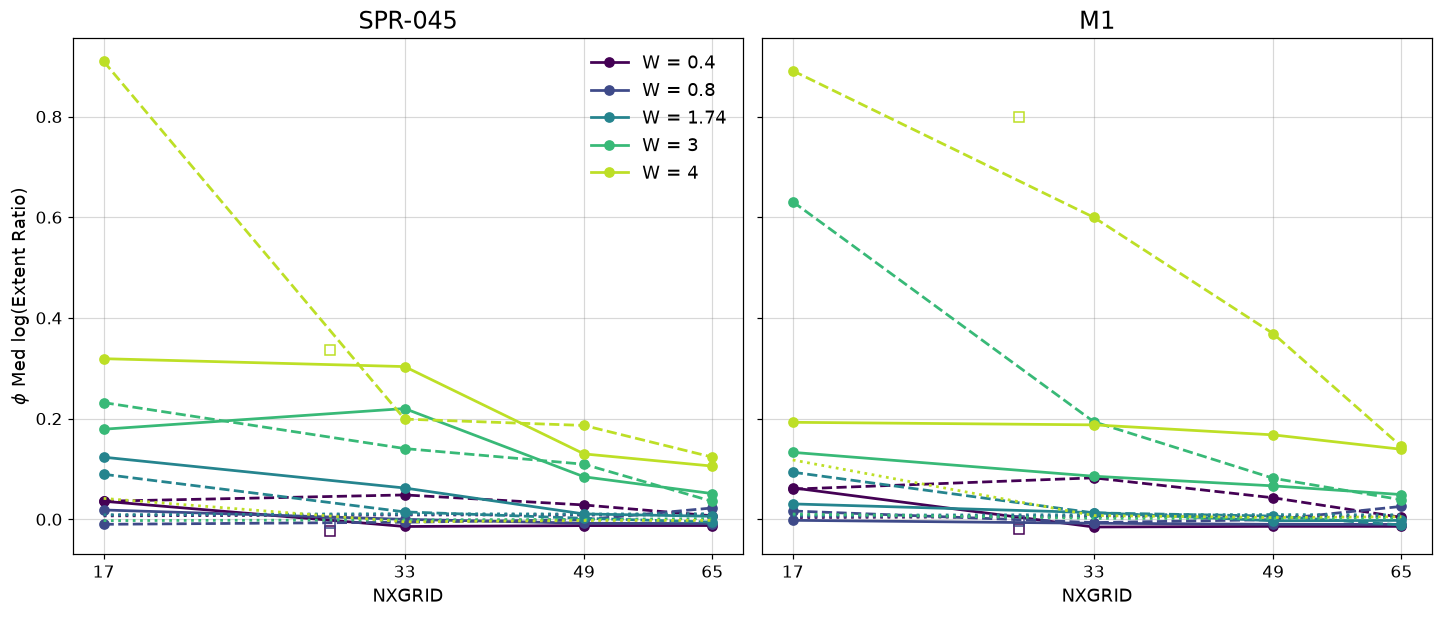

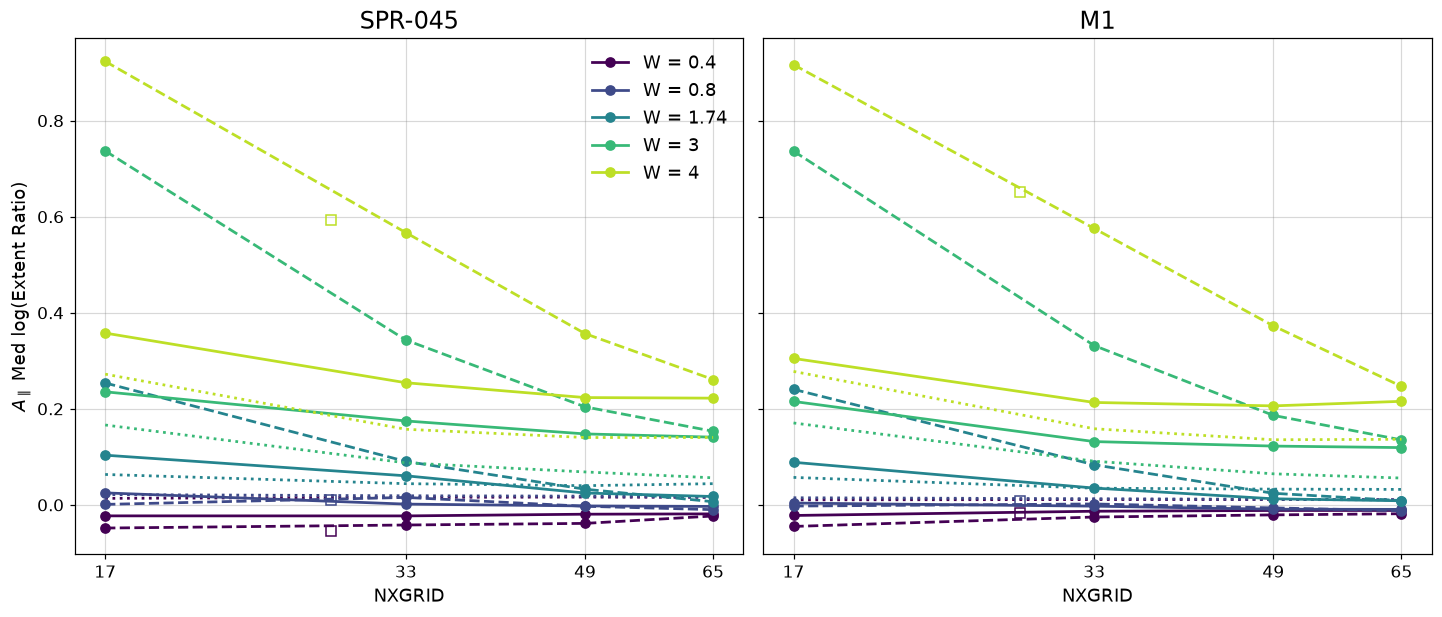

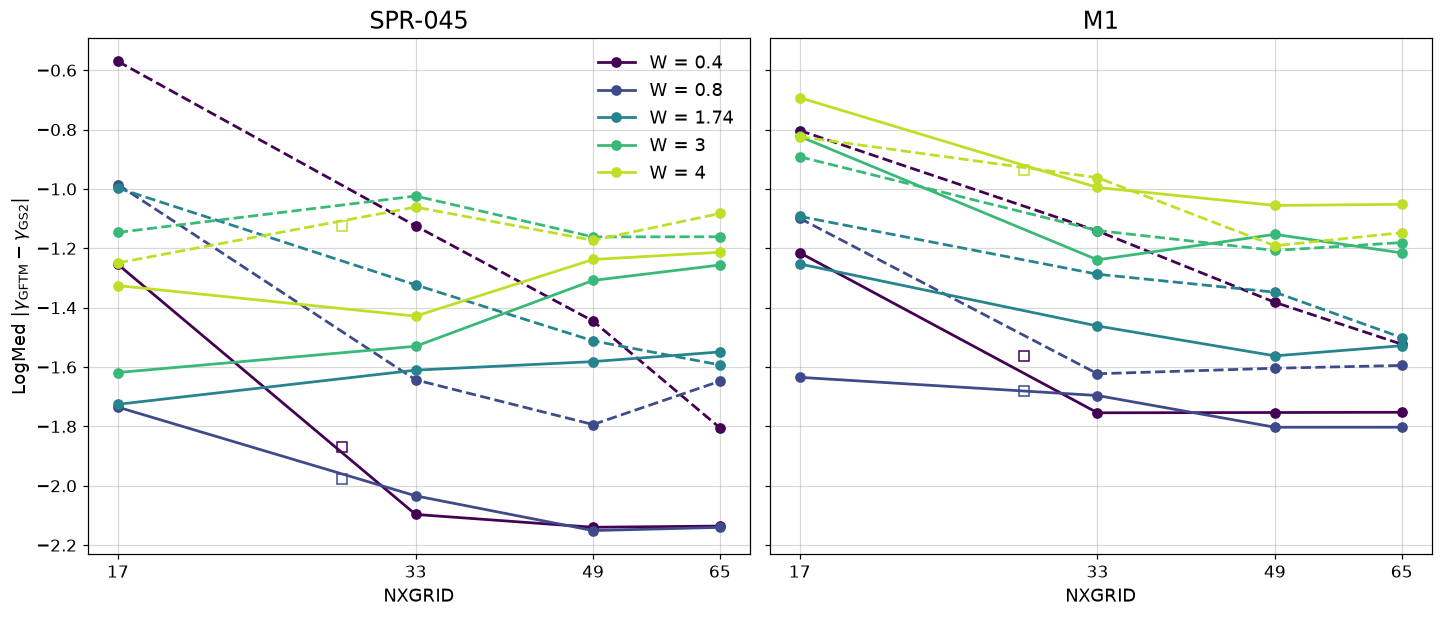

In [6]:
def vs_nxgrid(col, floor_col=None, ylabel="", fld=None):
    fig, axes = plt.subplots(1, len(cases), figsize=(13, 5.5), sharey=True, squeeze=False)
    for c, db in enumerate(cases):
        ax = axes[0, c]
        for W in widths:
            for arm, ls in zip(arms, ("-", "--")):
                d = summary[(summary.db == db) & (summary.W == W)]
                d = d.set_index(["nxgrid", "nbasis"]).loc[[(nx, arms[arm](nx)) for nx in nxgrids]]
                ax.plot(nxgrids, d[col], ls=ls, color=colours[W], label=f"W = {W:g}" if arm == "top" else None)
                if floor_col and arm == "top":
                    ax.plot(nxgrids, d[floor_col], ls=":", marker="", color=colours[W])
            if W in reuse:
                r = summary[(summary.db == db) & (summary.W == W) & (summary.nxgrid == 28)]
                ax.plot([28], r[col], ls="", marker="s", mfc="none", color=colours[W])
        ax.set(xscale="log", xlabel="NXGRID")
        ax.set_title(db, fontsize=fs_title)
        log_xticks(ax, nxgrids)
    axes[0, 0].set_ylabel(ylabel)
    axes[0, 0].legend(fontsize=fs_legend)
    plt.show()
    return fig


fig1 = vs_nxgrid("medlog_ext_phi", "medlog_floor_phi", r"$\phi$ Med log(Extent Ratio)")
fig2 = vs_nxgrid("medlog_ext_apar", "medlog_floor_apar", r"$A_\parallel$ Med log(Extent Ratio)")
fig3 = vs_nxgrid("logmed_gamma_err", None, r"LogMed $|\gamma_{\rm GFTM}-\gamma_{\rm GS2}|$")

fig4: which scale collapses the curves? Each point is one leaf: median phi log(Extent Ratio) against the leaf's
basis scale WIDTH/sqrt(2 NBASIS) (left) and its central node spacing pi WIDTH/sqrt(2(2 NXGRID-1)) (right), each over
the case's GS2 extent (median over the KBM population). If one of them makes the five WIDTH groups fall on one curve,
that is the scale that sets the extent.

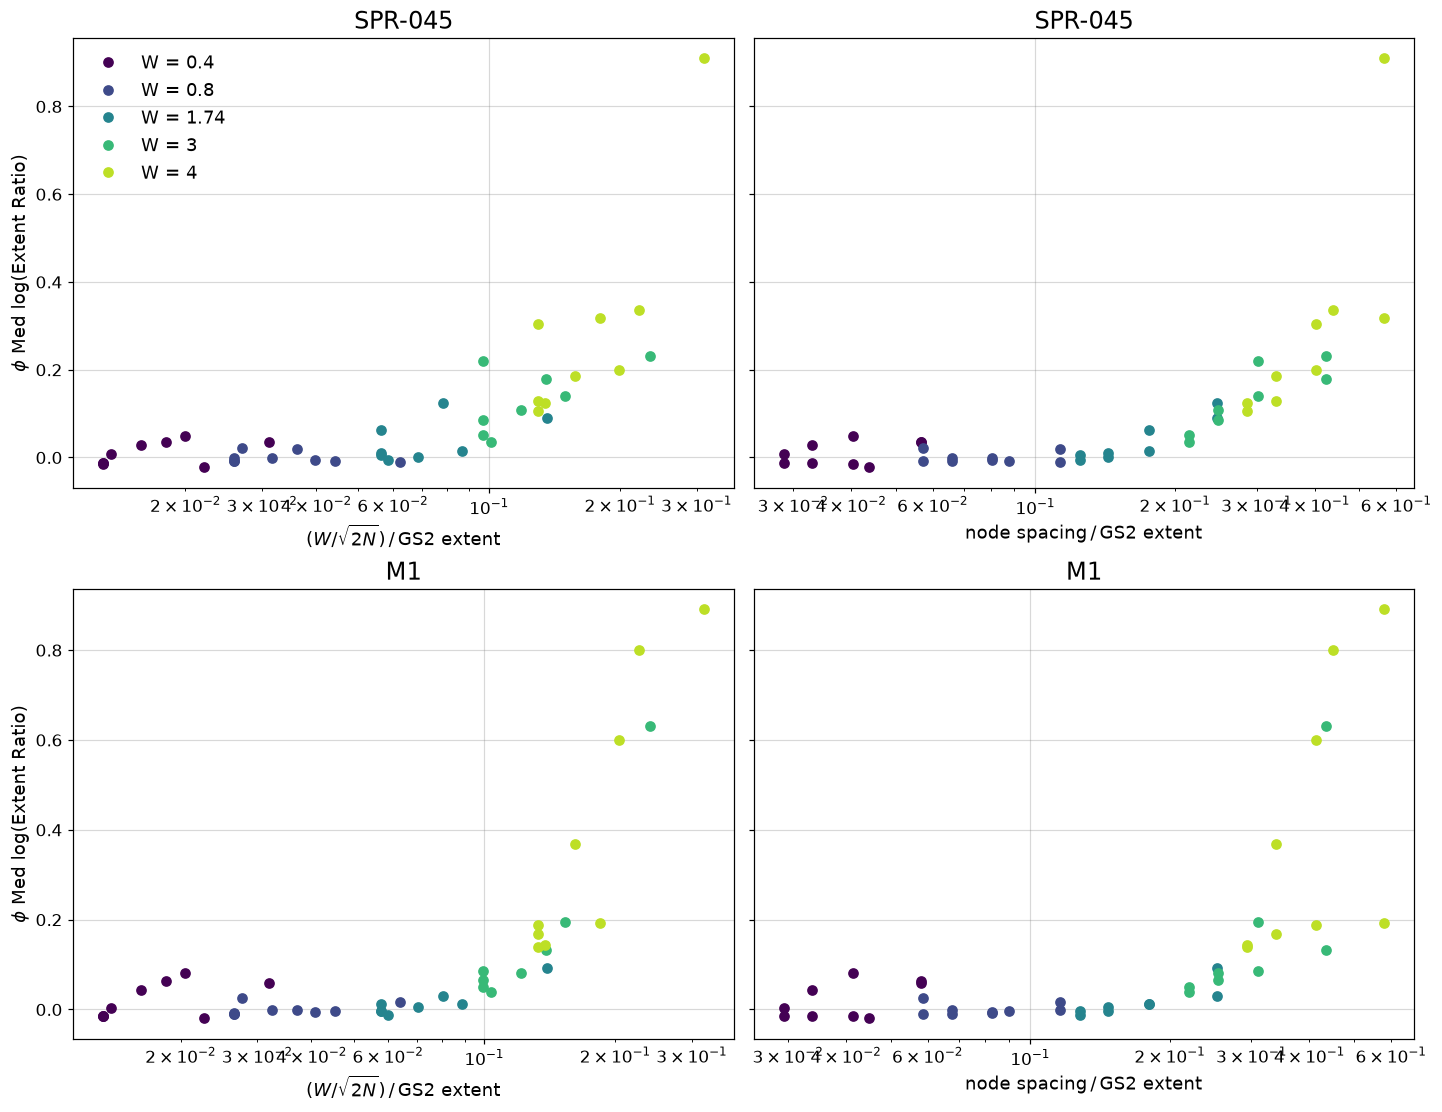

SPR-045 basis_scale | Spearman rho (pooled over WIDTH): 0.821
SPR-045 node_spacing | Spearman rho (pooled over WIDTH): 0.848
M1 basis_scale | Spearman rho (pooled over WIDTH): 0.822
M1 node_spacing | Spearman rho (pooled over WIDTH): 0.794


In [7]:
for db in cases:
    k = gs2[db]["kbm"]
    e_ref = np.median(gs2[db]["ext"]["phi"][k])
    s = summary.db == db
    summary.loc[s, "basis_scale"] = summary.W[s] / np.sqrt(2 * summary.nbasis[s]) / e_ref
    summary.loc[s, "node_spacing"] = np.pi * summary.W[s] / np.sqrt(2 * (2 * summary.nxgrid[s] - 1)) / e_ref
fig4, axes4 = plt.subplots(len(cases), 2, figsize=(13, 10), sharey="row", squeeze=False)
for r, db in enumerate(cases):
    for c, (col, lab) in enumerate((("basis_scale", r"$(W/\sqrt{2N})\,/\,$GS2 extent"), ("node_spacing", r"node spacing$\,/\,$GS2 extent"))):
        ax = axes4[r, c]
        for W in widths:
            d = summary[(summary.db == db) & (summary.W == W)]
            ax.plot(d[col], d.medlog_ext_phi, ls="", marker="o", color=colours[W], label=f"W = {W:g}")
        ax.set(xscale="log", xlabel=lab)
        ax.set_title(db, fontsize=fs_title)
    axes4[r, 0].set_ylabel(r"$\phi$ Med log(Extent Ratio)")
axes4[0, 0].legend(fontsize=fs_legend)
plt.show()
for db in cases:
    d = summary[summary.db == db]
    for col in ("basis_scale", "node_spacing"):
        # collapse: rank correlation of the extent ratio with the scale, pooled over WIDTH (1 = one monotone curve)
        print(db, col, "| Spearman rho (pooled over WIDTH):", round(float(d[[col, "medlog_ext_phi"]].corr(method="spearman").iloc[0, 1]), 3))

## Verdict numbers

Per WIDTH: phi median log(Extent Ratio) at the lowest and highest resolution of the top arm, and its spread over
WIDTH at the highest resolution (NXGRID 65, NBASIS 64). Converged = the change from NXGRID 49 to 65 is within the
output grid's quantisation (log10 1.02 ~ 0.009).

In [8]:
verdict = []
for db in cases:
    for W in widths:
        d = summary[(summary.db == db) & (summary.W == W)].set_index(["nxgrid", "nbasis"])
        top = [d.loc[(nx, arms["top"](nx))] for nx in nxgrids]
        verdict.append(dict(db=db, W=W, **{f"{f}_nx{nx}": t[f"medlog_ext_{f}"] for f in fields for nx, t in zip(nxgrids, top)},
                            phi_floor_nx65=top[-1]["medlog_floor_phi"], phi_change_49_65=top[-1].medlog_ext_phi - top[-2].medlog_ext_phi))
verdict = pd.DataFrame(verdict)
print(verdict.round(3).to_string(index=False))
for db in cases:
    v = verdict[verdict.db == db]
    print(db, "| spread over WIDTH at NXGRID 65 / NBASIS 64, phi:", round(float(v.phi_nx65.max() - v.phi_nx65.min()), 3),
          "A_par:", round(float(v.apar_nx65.max() - v.apar_nx65.min()), 3))

     db    W  phi_nx17  phi_nx33  phi_nx49  phi_nx65  apar_nx17  apar_nx33  apar_nx49  apar_nx65  phi_floor_nx65  phi_change_49_65
SPR-045 0.40     0.036    -0.014    -0.013    -0.013     -0.023     -0.023     -0.019     -0.019           0.009             0.000
SPR-045 0.80     0.018    -0.000    -0.008    -0.009      0.025      0.002     -0.002     -0.003           0.009            -0.001
SPR-045 1.74     0.123     0.062     0.010     0.006      0.103      0.060      0.025      0.017           0.011            -0.005
SPR-045 3.00     0.179     0.220     0.084     0.051      0.235      0.175      0.148      0.141           0.001            -0.033
SPR-045 4.00     0.319     0.303     0.130     0.106      0.358      0.254      0.223      0.222          -0.002            -0.024
     M1 0.40     0.062    -0.015    -0.014    -0.014     -0.022     -0.013     -0.012     -0.012           0.005            -0.000
     M1 0.80    -0.002    -0.008    -0.010    -0.010      0.004     -0.003     -0.0

## Accuracy vs WIDTH for each NBASIS (user, 2026-10-05)

One panel per NBASIS on the NXGRID - 6 arm (NBASIS 11/27/43/59 at NXGRID 17/33/49/65, five WIDTHs each) and the
existing NBASIS 22 / NXGRID 28 `wo_f05` scan (all its widths, 0.15-4). Two figures: LogMed |gamma err| vs WIDTH and
Med |log(Extent Ratio)| (phi, A_par) vs WIDTH, GS2-KBM population, dominant mode.

**Grey band = the representability rule (Part A)**: a mode of 95% extent E is held by the basis only if
sigma_min <= E/3.92 <= sigma_max, with sigma_min = c_lo W/sqrt(2N) and sigma_max = c_hi W sqrt(2N) measured on Gaussians
below, i.e. W in [E / (3.92 c_hi sqrt(2N)), E sqrt(2N) / (3.92 c_lo)], with E the GS2-KBM median phi extent.
**Red dotted line = measured largest accurate WIDTH**, from that figure's own metric: the largest WIDTH, contiguous upward
from the panel's most accurate one, with phi Med |log(Extent Ratio)| <= log10(1.12) (extent figure) or gamma medAE
<= 2x the panel's own best (growth figure).

sigma_min = 1.793 W/sqrt(2N), sigma_max = 0.621 W sqrt(2N) | ranges [1.734, 1.841] [0.607, 0.65]


NBASIS 22 widths: 59 w0p1500 ... w4p0000


widths per section: {11: 66, 22: 59, 27: 66, 43: 66, 59: 66}
            rule_lo  rule_hi  W_max_extent  W_max_gamma
SPR-045 11    0.239    1.824           NaN        1.449
        22    0.169    2.579         1.200        0.966
        27    0.153    2.858         1.000        1.000
        43    0.121    3.606         0.832        0.865
        59    0.103    4.224         0.696        0.764
M1      11    0.233    1.778         1.400        2.500
        22    0.165    2.515         1.400        1.149
        27    0.149    2.786         1.149        1.100
        43    0.118    3.515         2.308        1.500
        59    0.101    4.118         2.773        1.740


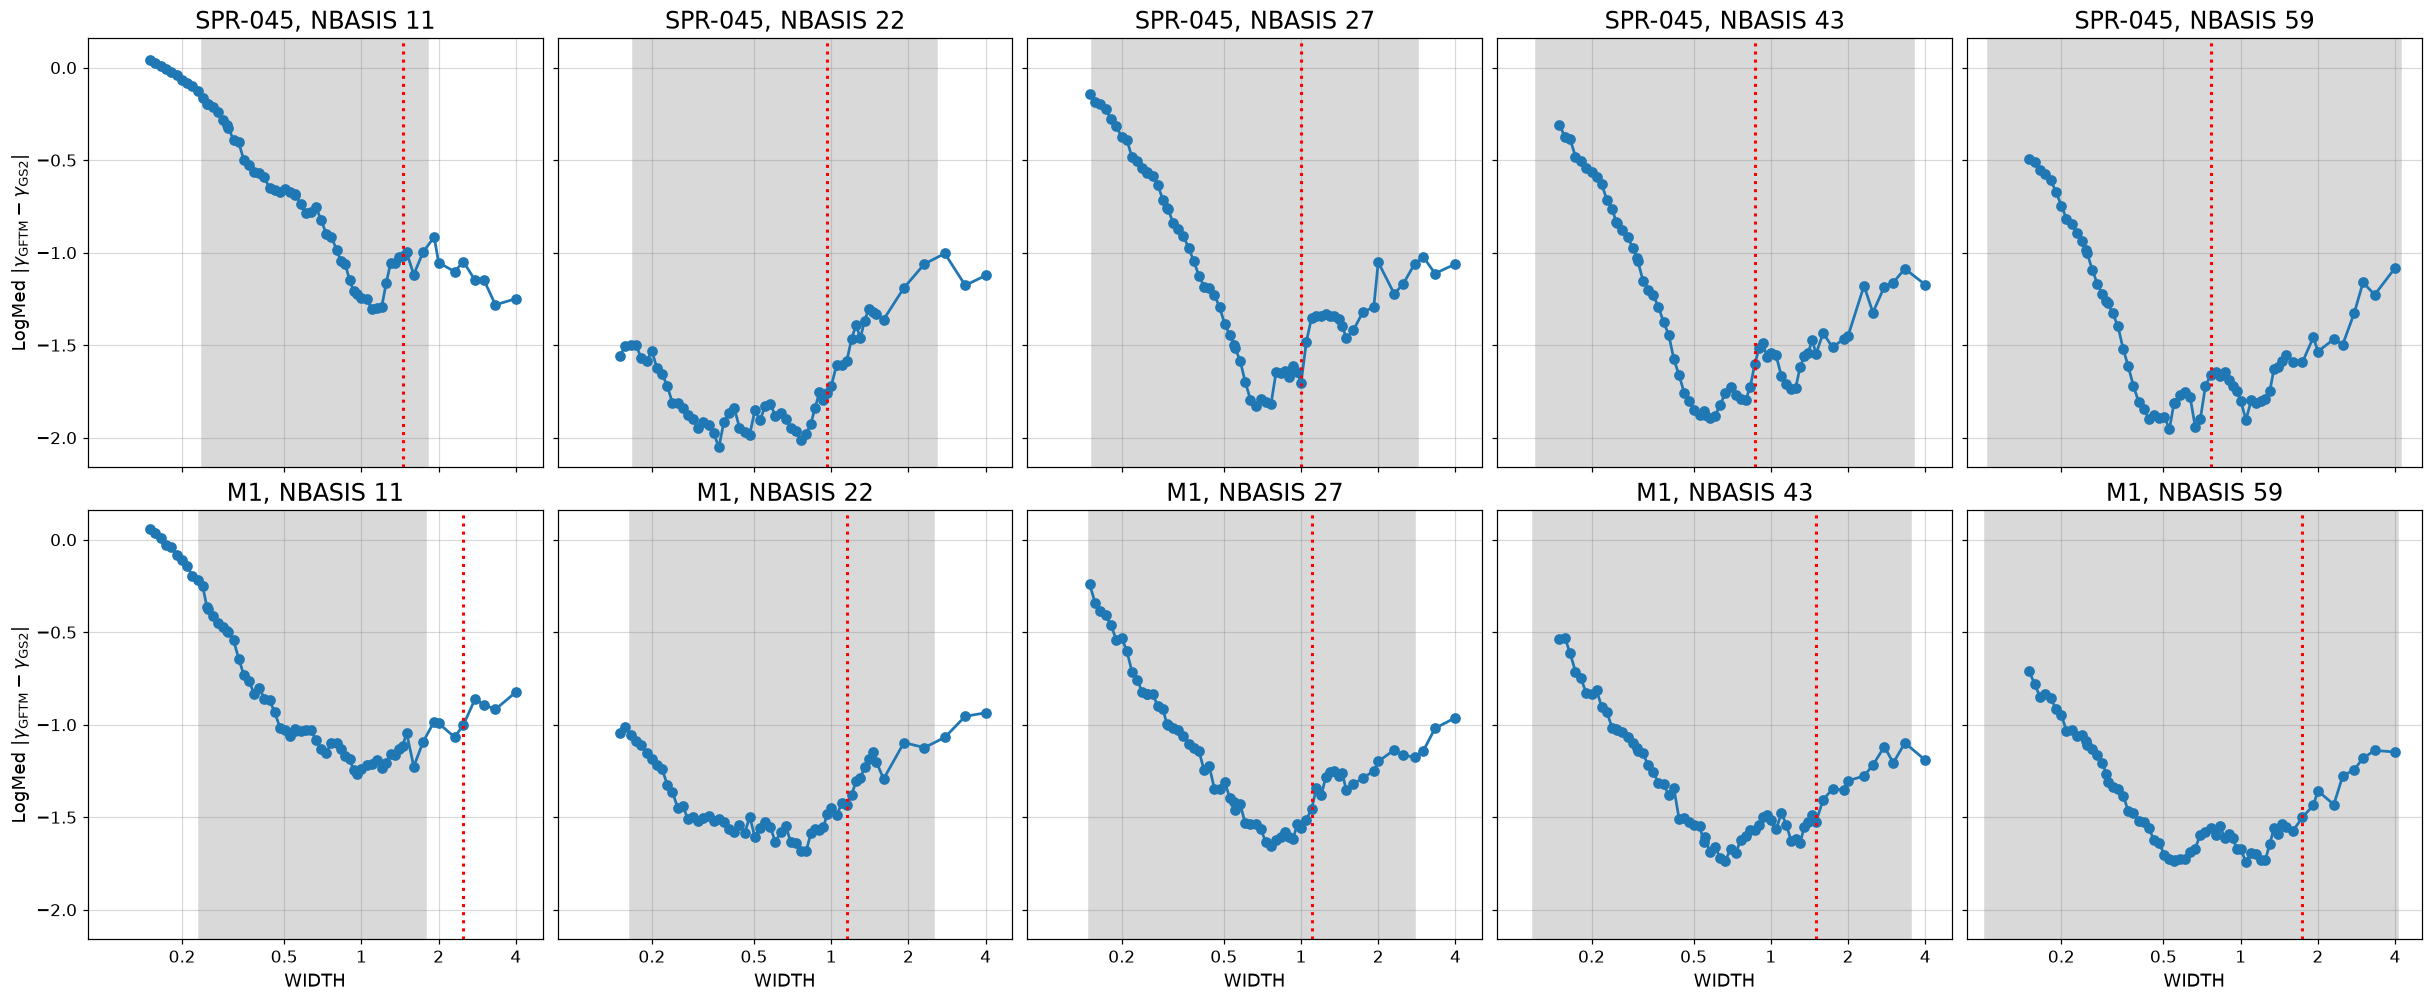

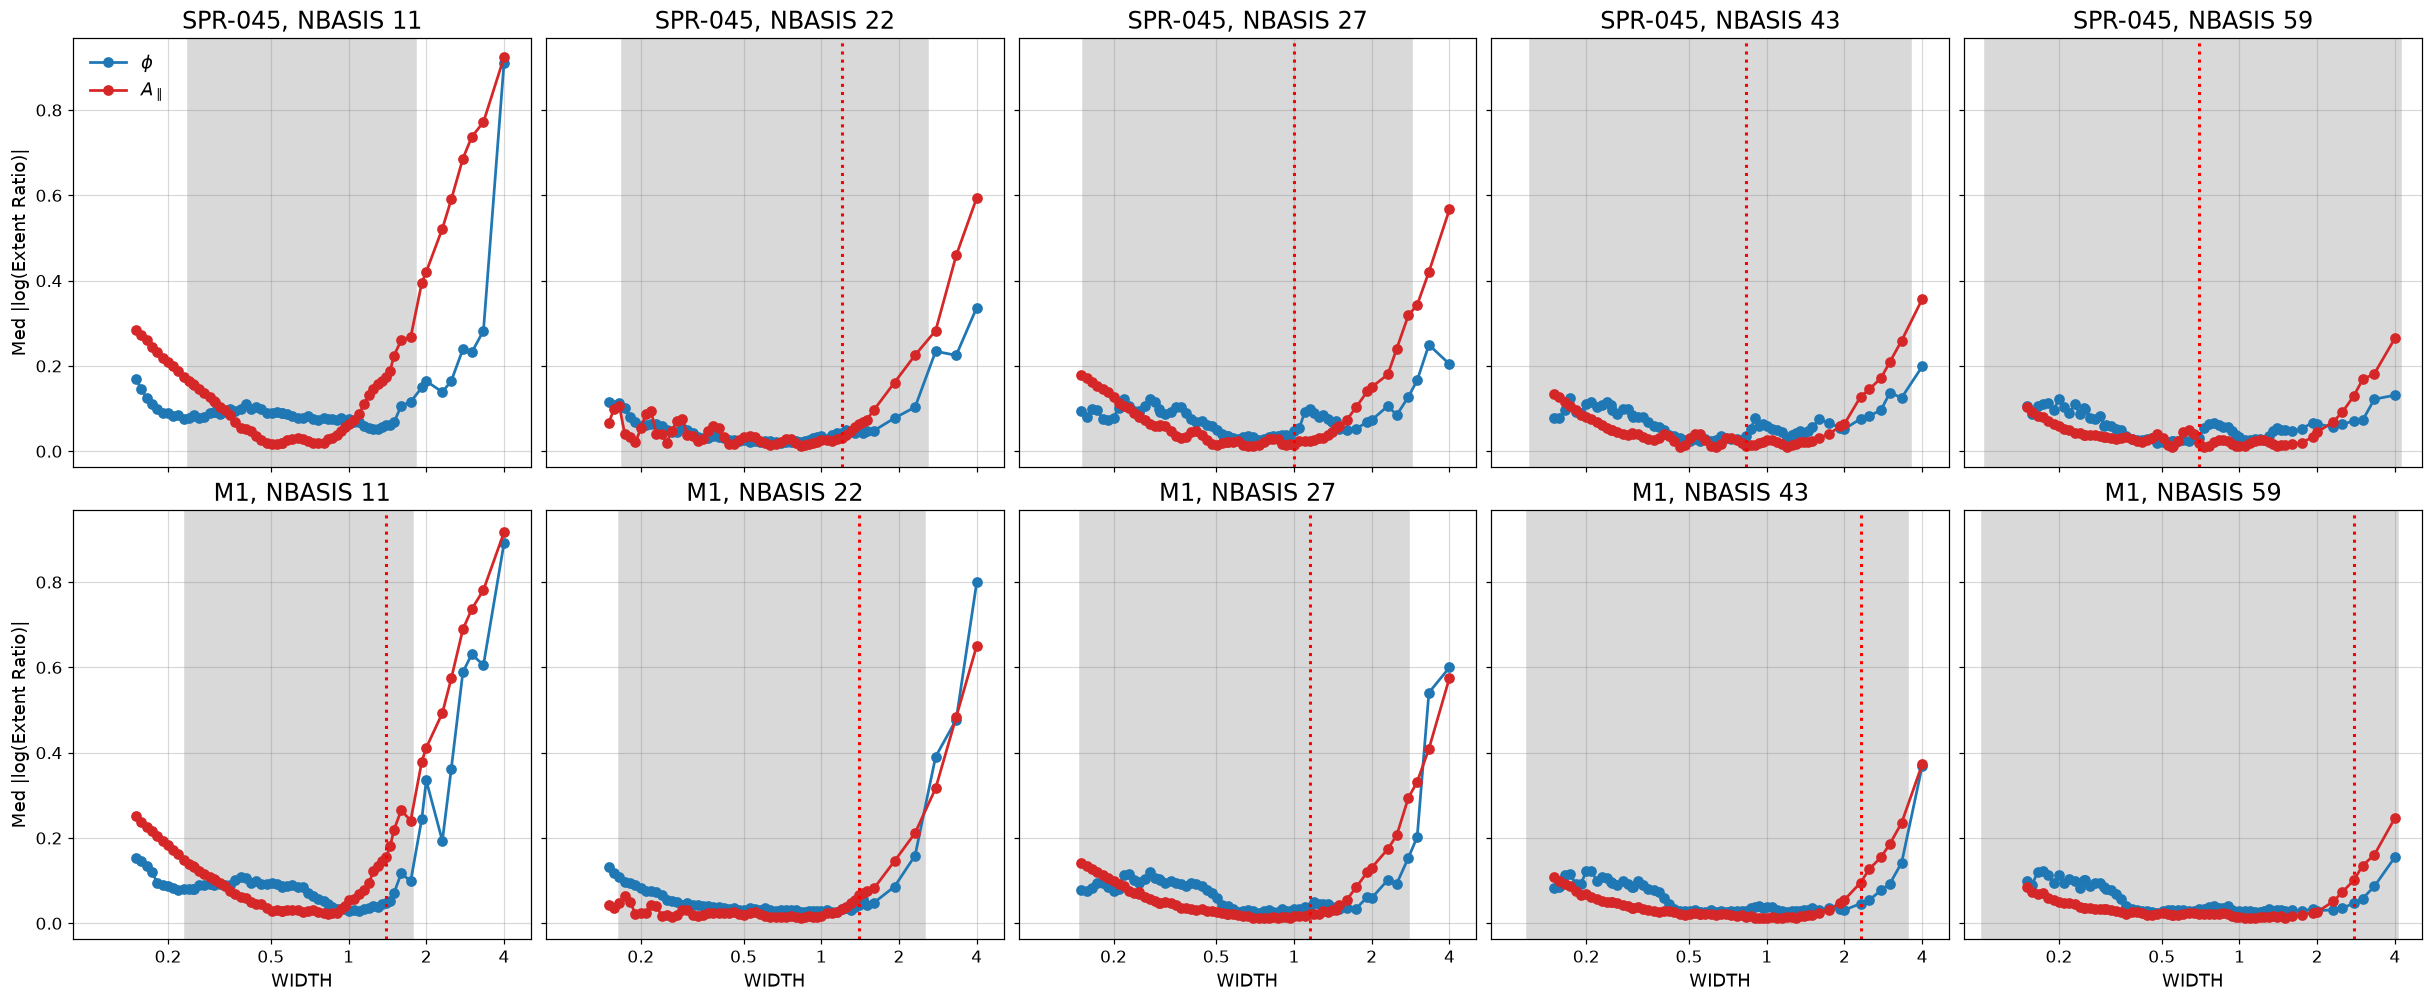

In [9]:
sig_grid = np.geomspace(0.03, 20, 160)
c = []
for W in (0.4, 1.0):
    for nx, nb in [(17, 11), (28, 22), (33, 27), (49, 43), (65, 59)]:
        ok = [s for s in sig_grid if 1 / 1.1 < gauss_ratio(s, W, nb, nx) < 1.1]
        c.append(dict(nb=nb, c_lo=min(ok) / (W / np.sqrt(2 * nb)), c_hi=max(ok) / (W * np.sqrt(2 * nb))))
c = pd.DataFrame(c)
c_lo, c_hi = c.c_lo.median(), c.c_hi.median()
print("sigma_min = %.3f W/sqrt(2N), sigma_max = %.3f W sqrt(2N)" % (c_lo, c_hi), "| ranges", c.c_lo.agg(["min", "max"]).round(3).tolist(), c.c_hi.agg(["min", "max"]).round(3).tolist())

# NBASIS 22 / NXGRID 28: every wo_f05 leaf (old leaves pyro_cube/cube.nc, newer GyroRun leaves pyroscan.nc)
wo_dir = lambda case: data_root / "GFTM" / "Runs" / project / case / "kbm_8d"
wo_tags = sorted({p.name[len("wo_f05_"):] for p in wo_dir("SPR-045").glob("wo_f05_w*")}, key=lambda t: float(t[1:].replace("p", ".")))
assert wo_tags == sorted({p.name[len("wo_f05_"):] for p in wo_dir("M1").glob("wo_f05_w*")}, key=lambda t: float(t[1:].replace("p", ".")))


def dominant(db, path):
    out = PyroScanGKOutput.from_netcdf(path)
    Extent(out, fraction=fraction)
    d = out.data
    idx = pd.Index(d.sample_name.values.astype(str)).get_indexer(gs2[db]["names"])
    assert (idx >= 0).all()
    gam = mag(d.growth_rate.transpose("sample", "mode"))[idx]
    g = np.where(gam > 0, gam, -np.inf)
    dom, has = g.argmax(1), np.isfinite(g.max(1))
    pick = lambda a: np.where(has, a[np.arange(len(a)), dom], np.nan)
    return dict(gamma=np.where(has, gam[np.arange(len(gam)), dom], 0.0),
                ext={f: pick(mag(d.extent.sel(field=f).transpose("sample", "mode"))[idx]) for f in fields})


for db, case in cases.items():
    for t in wo_tags:
        W = float(t[1:].replace("p", "."))
        if (db, W, 28, 22) not in gftm:
            base = wo_dir(case) / f"wo_f05_{t}"
            gftm[db, W, 28, 22] = dominant(db, base / ("pyro_cube/cube.nc" if (base / "pyro_cube/cube.nc").is_file() else "pyroscan.nc"))
print("NBASIS 22 widths:", len(wo_tags), wo_tags[0], "...", wo_tags[-1])

sections = {11: 17, 22: 28, 27: 33, 43: 49, 59: 65}   # NBASIS: NXGRID (NXGRID - 6 arm)
# every WIDTH of each NXGRID - 6 section: the 5 base widths plus the dense and full wo_f05-grid extensions (registry
# QX_WIDTHS_DENSE, QX_WIDTHS_FINE); NBASIS 22 is the wo_f05 scan loaded above
for db, case in cases.items():
    for nb, nx in sections.items():
        for leaf in [] if nb == 22 else wo_dir(case).glob(f"qx_f05_w*_nb{nb}_nx{nx}"):
            W = float(leaf.name.split("_")[2][1:].replace("p", "."))
            if (db, W, nx, nb) not in gftm:
                gftm[db, W, nx, nb] = dominant(db, leaf / "pyroscan.nc")
print("widths per section:", {nb: sum(1 for k in gftm if k[0] == "SPR-045" and k[2:] == (nx, nb)) for nb, nx in sections.items()})
acc = []
for db in cases:
    k = gs2[db]["kbm"]
    for (d_, W, nx, nb), e in gftm.items():
        if d_ != db or sections.get(nb) != nx:
            continue
        acc.append(dict(db=db, nb=nb, W=W, gamma_logmed=np.log10(np.median(np.abs(e["gamma"][k] - gs2[db]["gamma"][k]))),
                        **{f"ext_{f}": np.nanmedian(np.abs(np.log10(e["ext"][f][k] / gs2[db]["ext"][f][k]))) for f in fields}))
acc = pd.DataFrame(acc).sort_values(["db", "nb", "W"])
# measured largest accurate WIDTH, one per figure, contiguous upward from the panel's most accurate WIDTH:
#   extent: phi Med |log(Extent Ratio)| <= log10(1.12);  growth: medAE <= 2x the panel's own best
acc["ok_ext"] = acc.ext_phi <= np.log10(1.12)
acc["ok_gamma"] = acc.gamma_logmed <= acc.groupby(["db", "nb"]).gamma_logmed.transform("min") + np.log10(2)


def last_ok(a, metric, ok):
    i = int(a[metric].idxmin())
    while i + 1 < len(a) and a[ok][i + 1]:
        i += 1
    return a.W[i] if a[ok][i] else np.nan


w_rule, w_max_ext, w_max_gam = {}, {}, {}
for db in cases:
    E = np.median(gs2[db]["ext"]["phi"][gs2[db]["kbm"]])
    for nb in sections:
        w_rule[db, nb] = (E / (3.92 * c_hi * np.sqrt(2 * nb)), E * np.sqrt(2 * nb) / (3.92 * c_lo))
        a = acc[(acc.db == db) & (acc.nb == nb)].reset_index(drop=True)
        w_max_ext[db, nb], w_max_gam[db, nb] = last_ok(a, "ext_phi", "ok_ext"), last_ok(a, "gamma_logmed", "ok_gamma")
print(pd.DataFrame({"rule_lo": {k: v[0] for k, v in w_rule.items()}, "rule_hi": {k: v[1] for k, v in w_rule.items()},
                    "W_max_extent": w_max_ext, "W_max_gamma": w_max_gam}).round(3).to_string())


def per_nbasis(cols, labels, ylabel, w_max):
    fig, axes = plt.subplots(len(cases), len(sections), figsize=(22, 9), sharex=True, sharey=True, squeeze=False)
    for r, db in enumerate(cases):
        for j, nb in enumerate(sections):
            ax = axes[r, j]
            a = acc[(acc.db == db) & (acc.nb == nb)]
            for col, lab, cc in zip(cols, labels, ("C0", "C3")):
                ax.plot(a.W, a[col], color=cc, label=lab)
            ax.axvspan(*w_rule[db, nb], color="0.85", zorder=0)
            if np.isfinite(w_max[db, nb]):
                ax.axvline(w_max[db, nb], color="red", ls=":", lw=2, marker="")
            ax.set(xscale="log")
            ax.set_title(f"{db}, NBASIS {nb}", fontsize=fs_title)
            if r == len(cases) - 1:
                ax.set_xlabel("WIDTH")
                log_xticks(ax, [0.2, 0.5, 1, 2, 4])
        axes[r, 0].set_ylabel(ylabel)
    if len(cols) > 1:
        axes[0, 0].legend(fontsize=fs_legend)
    plt.show()
    return fig


fig5 = per_nbasis(["gamma_logmed"], [None], r"LogMed $|\gamma_{\rm GFTM}-\gamma_{\rm GS2}|$", w_max_gam)
fig6 = per_nbasis(["ext_phi", "ext_apar"], [field_labels["phi"], field_labels["apar"]], "Med |log(Extent Ratio)|", w_max_ext)

In [10]:
out = ROOT / "Plots" / analysis_name
out.mkdir(parents=True, exist_ok=True)
for name, fig in (("figA1_gaussian_collapse", figA1), ("fig1_phi_extent_vs_nxgrid", fig1), ("fig2_apar_extent_vs_nxgrid", fig2),
                  ("fig3_gamma_err_vs_nxgrid", fig3), ("fig4_extent_vs_scale", fig4),
                  ("fig5_gamma_err_vs_width_per_nbasis", fig5), ("fig6_extent_vs_width_per_nbasis", fig6)):
    fig.savefig(out / f"{name}.png", bbox_inches="tight")
summary.round(4).to_csv(out / "leaf_summary.csv", index=False)     # one row per leaf: medians only, no per-case rows
verdict.round(4).to_csv(out / "verdict.csv", index=False)
acc.round(4).to_csv(out / "accuracy_vs_width.csv", index=False)
print(sorted(p.name for p in out.iterdir()))

['accuracy_vs_width.csv', 'fig1_phi_extent_vs_nxgrid.png', 'fig2_apar_extent_vs_nxgrid.png', 'fig3_gamma_err_vs_nxgrid.png', 'fig4_extent_vs_scale.png', 'fig5_gamma_err_vs_width_per_nbasis.png', 'fig6_extent_vs_width_per_nbasis.png', 'figA1_gaussian_collapse.png', 'leaf_summary.csv', 'verdict.csv']
